### Contents:
 1. Loading up NCDF Files
 2. Lat & Lon Correction + subset for Norway
 3. T2m + Tp corrections (Temp to C from Kelvin; Tp from m to mm)
 4. Glacier names + location 
 5. T2m: Spatial + time series plot
 6. Tp: Spatial + time series plot
 7. T2m: Anomaly plot
 8. Tp: Anomaly plot
 9. T2m and Tp aggregation into seasons (accumulation: DJF and ablation: MJJAS)
 10. Computing final_df (master dataframe) with Glacier MB info + climate variable (seasonal) info
 11. Converting PC1 (NAO & AO) from monthly average into yearly data per season
 12. Appending final_df with PC1 and export
 13. Adding u10, v10, ssrd variables to final_df and exporting

#### Note: final_df export contains unweighted NAO and final_df2 export contains weighted NAO values with new variables (wind components, ssrd). final_df3 is the newest iteration with EA in it.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.linalg import svd
import dask
import matplotlib.ticker as mticker

In [2]:
file_path1 = r"C:\Users\danis\Desktop\Danish\ERA5 Data\t2m.nc"
file_path2 = r"C:\Users\danis\Desktop\Danish\ERA5 Data\tp.nc"
ds = xr.open_dataset(file_path1, chunks = {"valid_time": 50})
ds2= xr.open_dataset(file_path2, chunks = {"valid_time": 50})

In [3]:
t2m= ds['t2m']
tp= ds2['tp']

print(t2m)
print(tp)
print (tp.time)

print(tp.sizes)
print(tp.dims)
print(tp.coords)

<xarray.DataArray 't2m' (time: 902, latitude: 721, longitude: 1440)> Size: 4GB
dask.array<open_dataset-t2m, shape=(902, 721, 1440), dtype=float32, chunksize=(129, 103, 206), chunktype=numpy.ndarray>
Coordinates:
    number     int64 8B ...
  * time       (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2025-02-01
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver     (time) <U4 14kB dask.array<chunksize=(902,), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:        

In [4]:

lat= ds.latitude.values
lat_index= np.where((lat>=20) & (lat<=80))[0]
lon= ds.longitude.values
lon= np.where(lon>180, lon-360, lon)
lon_index= np.where((lon>=-90) & (lon <=20))[0]

t2m= t2m - 273.15
tp= tp * 1000 
#time= ds['time'].values
time_t2m= pd.to_datetime(ds['time'].values)
time_tp= pd.to_datetime(ds2['time'].values)

t2m['time'] = time_t2m
tp['time']  = time_tp

t2m_norway = t2m.sel(latitude=slice(72, 57), longitude=slice(4, 31))
tp_norway  = tp.sel(latitude=slice(72, 57), longitude=slice(4, 31))

t2m_avg= t2m_norway.mean(dim='time', skipna=True)
tp_avg = tp_norway.mean(dim='time', skipna=True)

#for time series plots!
t2m_ts= t2m_norway.mean(dim=['latitude', 'longitude'], skipna=True) #mean over norway
tp_ts= tp_norway.mean(dim=['latitude', 'longitude'], skipna=True)

t2m_ts_rolling= t2m_ts.rolling(time=10, center=True).mean() #smoothing for plotting later
tp_ts_rolling= tp_ts.rolling(time=10, center=True).mean()

In [5]:
print("TP min/max:", tp_avg_annual.min().values, tp_avg_annual.max().values)
#print("T2M min/max:", t2m_norway.min().values, t2m_norway.max().values)

TP min/max: 17.53019 97.85537


In [5]:
#for plotting on map
glacier_names = [
    "Ålfotbreen", "Austdalsbreen", "Engabreen", "Gråfjellsbrea",
    "Gråsubreen", "Hansebreen", "Hellstugubreen", "Langfjordjøkelen",
    "Nigardsbreen", "Rembesdalskåka", "Storbreen"
]

# Corresponding latitudes and longitudes
glacier_lats = [61.75, 61.65, 66.65, 60.00, 61.66, 61.75, 61.57, 70.17, 61.72, 60.54, 61.60]
glacier_lons = [5.65, 7.25, 13.85, 6.25, 8.60, 5.65, 8.44, 21.75, 7.13, 7.37, 8.13]

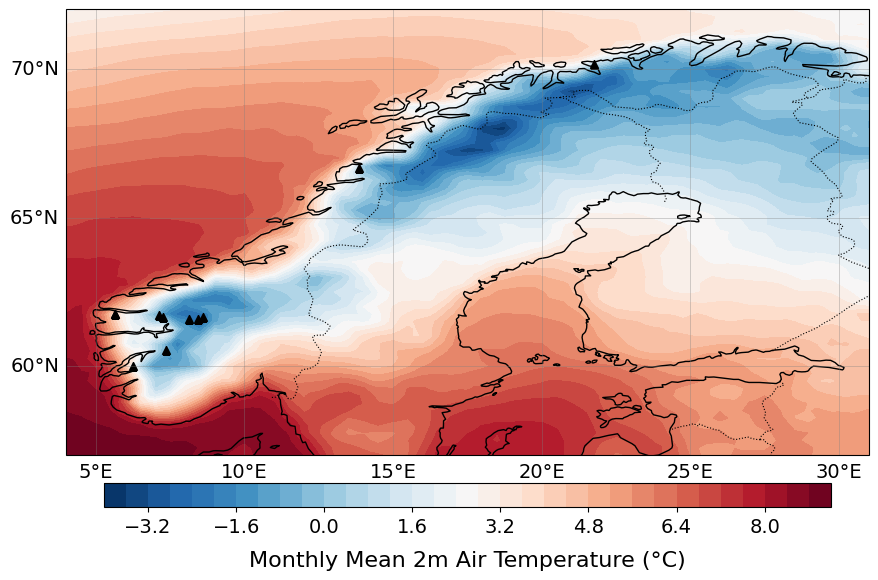

In [ ]:
#plt.figure(figsize=(10,6))
import matplotlib.ticker as mticker

#t2m_min = t2m_avg.min().compute().item()
#t2m_max = t2m_avg.max().compute().item()


fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
#plot1= t2m_avg.plot(ax=ax, cmap= 'RdBu_r', transform=ccrs.PlateCarree(), add_colorbar=False)
plot1 = ax.contourf(t2m_avg['longitude'], t2m_avg['latitude'], t2m_avg.compute(),
                    levels=40, cmap='RdBu_r', transform=ccrs.PlateCarree())
ax.plot(glacier_lons, glacier_lats, marker='^', markersize= 6, color= 'black', 
        linestyle='none', transform=ccrs.PlateCarree())

#contour_levels = np.arange(t2m_min, t2m_max, 1.0)  # every 1°C
#contours = ax.contour(t2m_avg['longitude'], t2m_avg['latitude'], t2m_avg,
                     # levels=contour_levels,
                     # colors='white', linewidths=0.25, transform=ccrs.PlateCarree())

ax.coastlines(resolution='50m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
gl= ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5)
gl.xlocator = mticker.FixedLocator(range(0, 40, 5))   # longitudes from 0 to 35 every 5°
gl.ylocator = mticker.FixedLocator(range(55, 75, 5)) 
gl.xlabel_style = {'size': 14}
gl.ylabel_style = {'size': 14}

gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False

cb = plt.colorbar(plot1, ax=ax, shrink=0.75, pad=0.05, aspect=30, orientation='horizontal')
cb.ax.tick_params(labelsize=14)
cb.set_label('Monthly Mean 2m Air Temperature (°C)', labelpad= 10, fontsize=16)

#plt.title('Monthly mean 2m Air Temp', size=14)
plt.tight_layout()
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\03- Climate Variables\avg_monthly_t2m.png", dpi=800, bbox_inches='tight')
plt.show()

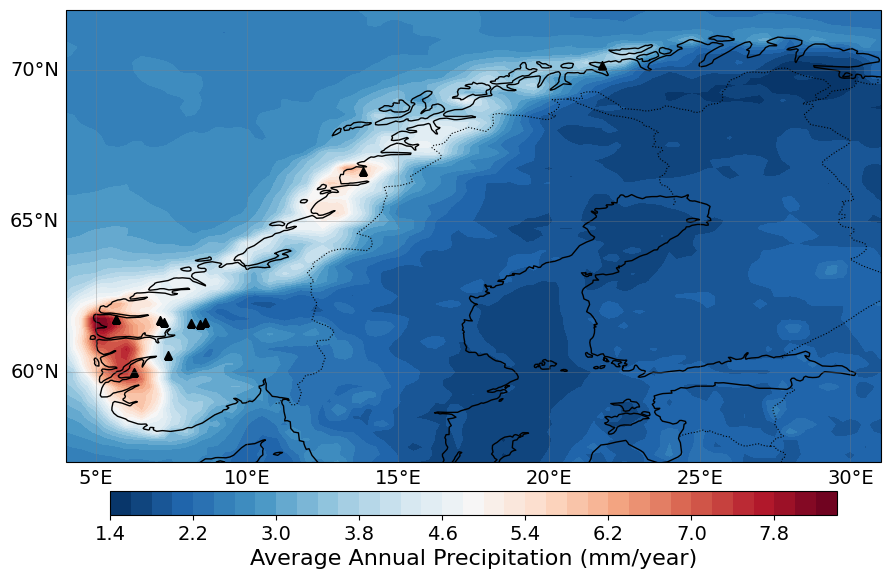

In [15]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
plot1 = ax.contourf(tp_avg['longitude'], tp_avg['latitude'], tp_avg.compute(),
                    levels=40, cmap='RdBu_r', transform=ccrs.PlateCarree())
ax.plot(glacier_lons, glacier_lats, marker='^', markersize= 6, color= 'black', 
        linestyle='none', transform=ccrs.PlateCarree())


ax.coastlines(resolution='50m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
gl= ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5)
gl.xlocator = mticker.FixedLocator(range(0, 40, 5))   # longitudes from 0 to 35 every 5°
gl.ylocator = mticker.FixedLocator(range(55, 75, 5))
gl.xlabel_style = {'size': 14}
gl.ylabel_style = {'size': 14}

gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False

cb = plt.colorbar(plot1, ax=ax, shrink=0.75, pad=0.05, aspect=30, orientation= 'horizontal')
cb.ax.tick_params(labelsize=14)
cb.set_label('Average Annual Precipitation (mm/year)', fontsize=16)

#plt.title('Monthly mean Precipitation', size=14)
plt.tight_layout()
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\03- Climate Variables\avg_monthly_tp.png", dpi=800, bbox_inches='tight')
plt.show()

#### Annual total precipitation

In [10]:
# to compute average annual precip, need to weight days in each month before aggregating (sum)

# Getting days per month
tp_days_per_month = tp['time'].dt.days_in_month

# Converting to mm/month-total
tp_monthly_total_mm = tp * xr.DataArray(tp_days_per_month.values, dims='time')  # mm * days = mm/month-total

# Subsetting to Norway for corrected totals
tp_total_norway = tp_monthly_total_mm.sel(latitude=slice(72, 57), longitude=slice(4, 31))

# Aggregating to annual total (mm/year)
tp_annual_total = tp_total_norway.groupby('time.year').sum(dim='time')  # sum 12 months

# Computing long-term mean annual precipitation
tp_annual_total_mean = tp_annual_total.mean(dim='year')  # final map: mm/year


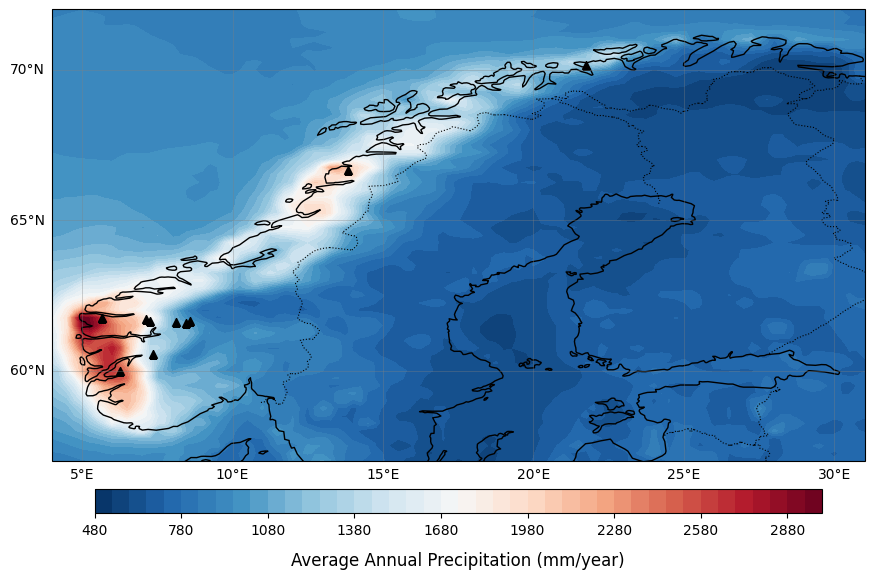

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
plot1 = ax.contourf(tp_annual_total_mean['longitude'], tp_annual_total_mean['latitude'], tp_annual_total_mean.compute(),
                    levels=40, cmap='RdBu_r', transform=ccrs.PlateCarree())
ax.plot(glacier_lons, glacier_lats, marker='^', markersize= 6, color= 'black', 
        linestyle='none', transform=ccrs.PlateCarree())


ax.coastlines(resolution='50m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
gl= ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5)
gl.xlocator = mticker.FixedLocator(range(0, 40, 5))   # longitudes from 0 to 35 every 5°
gl.ylocator = mticker.FixedLocator(range(55, 75, 5)) 
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False

cb = plt.colorbar(plot1, ax=ax, shrink=0.75, pad=0.05, aspect=30, orientation= 'horizontal')
cb.set_label('Average Annual Precipitation (mm/year)', labelpad=10, fontsize=12)

#plt.title('Annual mean Precipitation', size=14)
plt.tight_layout()
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\Presentation 0407\avg_annual_tp.png", dpi=800, bbox_inches='tight')
plt.show()

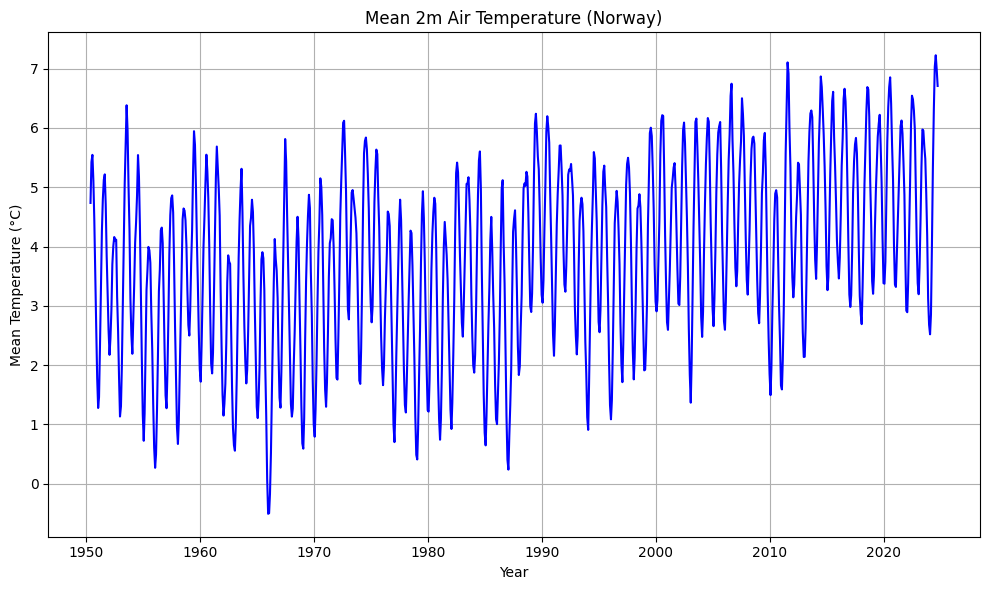

In [7]:
plt.figure(figsize=(10,6))
plt.plot(time_t2m, t2m_ts_rolling, color='blue', linewidth=1.5) # 10y rolling mean
plt.title('Mean 2m Air Temperature (Norway)', size=12)
plt.xlabel("Year")
plt.ylabel("Mean Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

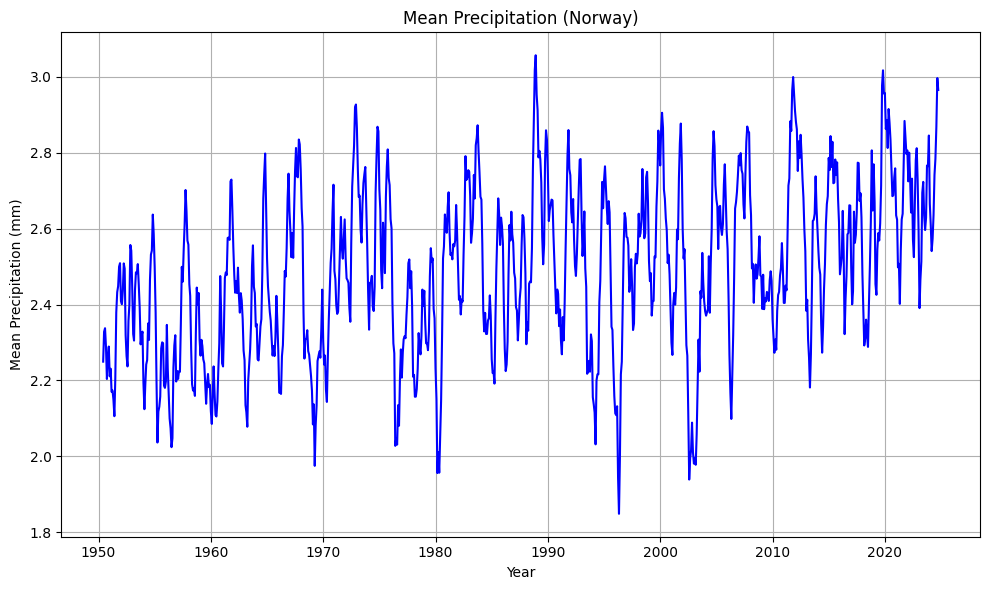

In [8]:
plt.figure(figsize=(10,6))
plt.plot(time_tp, tp_ts_rolling, color='blue', linewidth=1.5) # 10y rolling mean
plt.title('Mean Precipitation (Norway)', size=12)
plt.xlabel("Year")
plt.ylabel("Mean Precipitation (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
#anom plot

t2m_pre2k= t2m_norway.sel(valid_time=slice('1950', '1999')).mean(dim='valid_time')
t2m_post2k= t2m_norway.sel(valid_time=slice('2000', '2024')).mean(dim='valid_time')

t2m_anom= t2m_post2k - t2m_pre2k
t2m_anom.shape


tp_pre2k= tp_norway.sel(valid_time=slice('1950', '1999')).mean(dim='valid_time')
tp_post2k= tp_norway.sel(valid_time=slice('2000', '2024')).mean(dim='valid_time')

tp_anom= tp_post2k -tp_pre2k
tp_anom.shape

(61, 109)

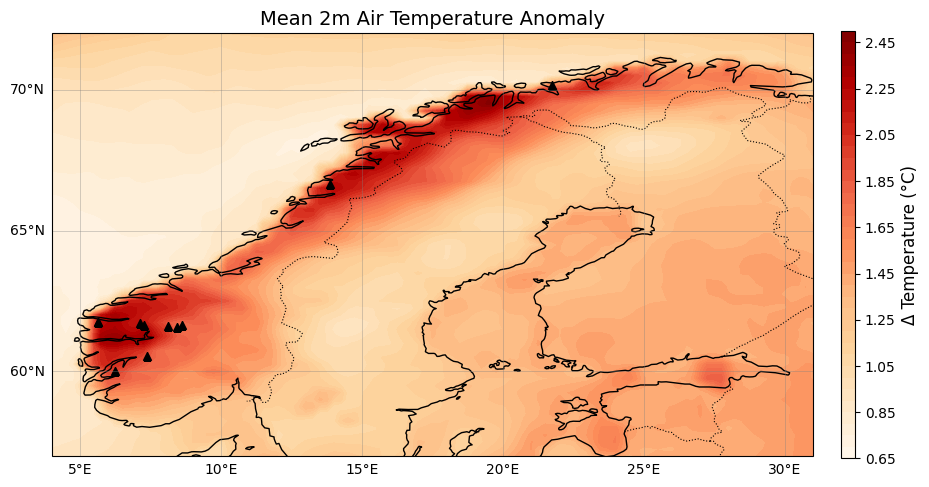

In [10]:
# temp anomalies plot
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
plot1 = ax.contourf(t2m_anom['longitude'], t2m_anom['latitude'], t2m_anom.compute(),
                    levels=40, cmap='OrRd', transform=ccrs.PlateCarree()) #Reds, OrRd, PuBu 1 color scales
ax.plot(glacier_lons, glacier_lats, marker='^', markersize= 6, color= 'black', 
        linestyle='none', transform=ccrs.PlateCarree())


ax.coastlines(resolution='50m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
gl= ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5)
gl.xlocator = mticker.FixedLocator(range(0, 40, 5))   # longitudes from 0 to 35 every 5°
gl.ylocator = mticker.FixedLocator(range(55, 75, 5)) 
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False

cb = plt.colorbar(plot1, ax=ax, shrink=0.75, pad=0.03, aspect=30)
cb.set_label('Δ Temperature (°C)', fontsize=12)

plt.title('Mean 2m Air Temperature Anomaly', size=14)
plt.tight_layout()
#plt.savefig('t2m_anom_norway3.png', dpi=800, bbox_inches='tight')
plt.show()

In [11]:
tp_anom_min = tp_anom.min().compute().item()
tp_anom_max = tp_anom.max().compute().item()
print(tp_anom_min, tp_anom_max)


-0.11132216453552246 0.9220147132873535


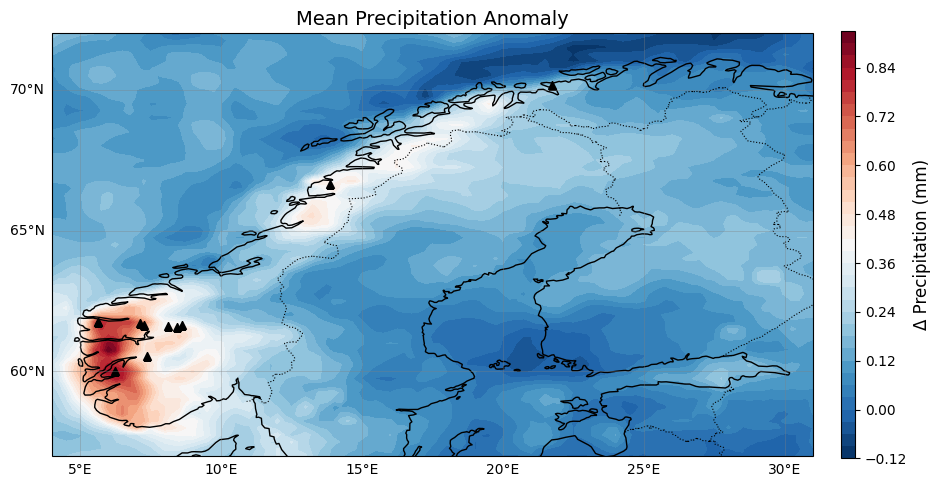

In [12]:
# temp anomalies plot
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
plot1 = ax.contourf(tp_anom['longitude'], tp_anom['latitude'], tp_anom.compute(),
                    levels=40, cmap='RdBu_r', transform=ccrs.PlateCarree())
ax.plot(glacier_lons, glacier_lats, marker='^', markersize= 6, color= 'black', 
        linestyle='none', transform=ccrs.PlateCarree())


ax.coastlines(resolution='50m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
gl= ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5)
gl.xlocator = mticker.FixedLocator(range(0, 40, 5))   # longitudes from 0 to 35 every 5°
gl.ylocator = mticker.FixedLocator(range(55, 75, 5)) 
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False

cb = plt.colorbar(plot1, ax=ax, shrink=0.75, pad=0.03, aspect=30)
cb.set_label('Δ Precipitation (mm)', fontsize=12)

plt.title('Mean Precipitation Anomaly', size=14)
plt.tight_layout()
#plt.savefig('tp_anom_norway.png', dpi=800, bbox_inches='tight')
plt.show()

In [4]:
time_t2m= pd.to_datetime(ds['valid_time'].values)
time_tp= pd.to_datetime(ds2['valid_time'].values)

months= pd.to_datetime(ds['valid_time'].values).month
djf_index = np.where(np.isin(months, [12, 1, 2]))[0]
mjjas_index= np.where(np.isin(months, [5, 6, 7, 8, 9]))[0]

In [5]:
t2m_series= pd.Series(t2m_ts.values, index= pd.to_datetime(t2m_ts['valid_time'].values))
tp_series= pd.Series(tp_ts.values, index= pd.to_datetime(tp_ts['valid_time'].values))

seasonal_df= pd.DataFrame({
    'Year': t2m_series.index.year,
    'Month': t2m_series.index.month,
    'Temp': t2m_series.values,
    'Precip': tp_series.values
})

seasonal_df['DJF_year'] = seasonal_df['Year']
seasonal_df.loc[seasonal_df['Month'] == 12, 'DJF_year'] += 1
print(seasonal_df.head())

   Year  Month      Temp    Precip  DJF_year
0  1950      1 -6.908786  1.837807      1950
1  1950      2 -4.343198  2.361129      1950
2  1950      3 -1.646112  2.428895      1950
3  1950      4  2.750050  2.639426      1950
4  1950      5  5.343435  1.496179      1950


In [6]:
# aggregating DJF into a df
djf_df= seasonal_df[seasonal_df['Month'].isin([12, 1, 2])]
djf_summary= djf_df.groupby('DJF_year').agg(
    Temp_DJF= ('Temp', 'mean'),
    Precip_DJF= ('Precip', 'sum')
).reset_index().rename(columns={'DJF_year': 'Year'})

In [7]:
# aggregating MJJAS into a df
df_mjjas = seasonal_df[seasonal_df["Month"].isin([5, 6, 7, 8, 9])]
mjjas_summary = df_mjjas.groupby("Year").agg(
    Temp_MJJAS=("Temp", "mean"),
    Precip_MJJAS=("Precip", "sum")
).reset_index()


In [8]:
seasonal_climate_df = pd.merge(djf_summary, mjjas_summary, on="Year", how="outer")
print(seasonal_climate_df.head())

   Year  Temp_DJF  Precip_DJF  Temp_MJJAS  Precip_MJJAS
0  1950 -5.625992    4.198936   10.414413     10.569879
1  1951 -4.362798    6.185266    9.747061     10.721021
2  1952 -2.419369    8.807426    9.220020     12.433246
3  1953 -5.094279    7.743274   10.786901     11.524487
4  1954 -3.825318    5.963656   10.494399     12.956203


In [9]:
# loading in data from prev scripts to merge
import pickle
with open("eof_data_weighted.pkl", "rb") as f:
    eof_data_weighted = pickle.load(f)
    
with open('glacier_data.pkl', "rb") as f:
    glacier_data = pickle.load(f)

print(eof_data_weighted.keys())
print(glacier_data.keys())

dict_keys(['EOF1_DJF', 'EOF2_DJF', 'PC1_DJF', 'PC2_DJF', 'PC1_std_DJF', 'PC2_std_DJF', 'EOF1_MJJAS', 'EOF2_MJJAS', 'PC1_MJJAS', 'PC2_MJJAS', 'PC1_std_MJJAS', 'PC2_std_MJJAS', 'PC1_AO', 'EOF_AO_map', 'EOF1_AO'])
Index(['Year', 'GlacierId', 'Glacier', 'Bs', 'Bw', 'Ba', 'Region',
       'Cumulative_Ba', 'Rolling_Bs', 'Rolling_Bw'],
      dtype='object')


In [10]:
final_df= pd.merge(seasonal_climate_df, glacier_data, on='Year', how='inner')
final_df['Period']= np.where(final_df['Year'] < 2000, 'Before_2000', 'After_2000')
print(final_df.head())

   Year  Temp_DJF  Precip_DJF  Temp_MJJAS  Precip_MJJAS  GlacierId    Glacier  \
0  1950 -5.625992    4.198936   10.414413     10.569879       2636  Storbreen   
1  1951 -4.362798    6.185266    9.747061     10.721021       2636  Storbreen   
2  1952 -2.419369    8.807426    9.220020     12.433246       2636  Storbreen   
3  1953 -5.094279    7.743274   10.786901     11.524487       2636  Storbreen   
4  1954 -3.825318    5.963656   10.494399     12.956203       2636  Storbreen   

     Bs    Bw    Ba Region  Cumulative_Ba  Rolling_Bs  Rolling_Bw       Period  
0 -1.81  1.52 -0.29  South          -0.09         NaN         NaN  Before_2000  
1 -1.67  1.13 -0.54  South          -0.63      -1.788       1.554  Before_2000  
2 -1.13  1.44  0.31  South          -0.32      -1.768       1.340  Before_2000  
3 -2.25  1.40 -0.85  South          -1.17      -1.818       1.350  Before_2000  
4 -1.98  1.21 -0.77  South          -1.94      -1.780       1.386  Before_2000  


### Seasonal aggregation for DJF

In [11]:
# creating one value per DJF season per year:
PC1_DJF= eof_data_weighted['PC1_DJF']
PC1_std_DJF= eof_data_weighted['PC1_std_DJF']
print(PC1_std_DJF[:10])

[-0.55343116 -0.59004469  1.15257876 -0.04333896  0.22465571 -1.03109346
 -0.64421305  1.49384207  0.79362419  0.34723793]


In [12]:
# merging PC1 DJF with my dataframe

PC1_std_DJF= PC1_std_DJF[:len(PC1_std_DJF) // 3*3]

pc1_matrix= np.reshape(PC1_std_DJF, (-1, 3)) # reshaping where each row is one season; -1 is asking to decide how many ever rows needed to reshape it into 3 columns for each month
pc1_seasonal= np.mean(pc1_matrix, axis=1)
years_djf= np.arange(1950, 1950+ len(pc1_seasonal))

pc1_djf_df= pd.DataFrame({
    'Year': years_djf,
    'PC1_DJF': pc1_seasonal
})
print(pc1_djf_df.head())
final_df= pd.merge(final_df, pc1_djf_df, on='Year', how='inner')
print(final_df.head())

   Year   PC1_DJF
0  1950  0.003034
1  1951 -0.283259
2  1952  0.547751
3  1953  0.155957
4  1954  0.135450
   Year  Temp_DJF  Precip_DJF  Temp_MJJAS  Precip_MJJAS  GlacierId    Glacier  \
0  1950 -5.625992    4.198936   10.414413     10.569879       2636  Storbreen   
1  1951 -4.362798    6.185266    9.747061     10.721021       2636  Storbreen   
2  1952 -2.419369    8.807426    9.220020     12.433246       2636  Storbreen   
3  1953 -5.094279    7.743274   10.786901     11.524487       2636  Storbreen   
4  1954 -3.825318    5.963656   10.494399     12.956203       2636  Storbreen   

     Bs    Bw    Ba Region  Cumulative_Ba  Rolling_Bs  Rolling_Bw  \
0 -1.81  1.52 -0.29  South          -0.09         NaN         NaN   
1 -1.67  1.13 -0.54  South          -0.63      -1.788       1.554   
2 -1.13  1.44  0.31  South          -0.32      -1.768       1.340   
3 -2.25  1.40 -0.85  South          -1.17      -1.818       1.350   
4 -1.98  1.21 -0.77  South          -1.94      -1.780       

### Seasonal aggregation for MJJAS

In [13]:
# merging PC1 MJJAS with my dataframe

PC1_std_MJJAS= eof_data_weighted['PC1_std_MJJAS']
PC1_std_MJJAS= PC1_std_MJJAS[:len(PC1_std_DJF) // 3*3]

pc1_mjjas_matrix= np.reshape(PC1_std_MJJAS, (-1, 3)) # reshaping where each row is one season; -1 is asking to decide how many ever rows needed to reshape it into 3 columns for each month
pc1_seasonal_mjjas= np.mean(pc1_mjjas_matrix, axis=1)
years_mjjas= np.arange(1950, 1950+ len(pc1_seasonal_mjjas))

pc1_mjjas_df= pd.DataFrame({
    'Year': years_mjjas,
    'PC1_MJJAS': pc1_seasonal_mjjas
})
print(pc1_mjjas_df.head())
final_df= pd.merge(final_df, pc1_mjjas_df, on='Year', how='inner')
print(final_df.head())


   Year  PC1_MJJAS
0  1950   0.438555
1  1951  -0.373563
2  1952   0.265765
3  1953  -0.717093
4  1954   0.272802
   Year  Temp_DJF  Precip_DJF  Temp_MJJAS  Precip_MJJAS  GlacierId    Glacier  \
0  1950 -5.625992    4.198936   10.414413     10.569879       2636  Storbreen   
1  1951 -4.362798    6.185266    9.747061     10.721021       2636  Storbreen   
2  1952 -2.419369    8.807426    9.220020     12.433246       2636  Storbreen   
3  1953 -5.094279    7.743274   10.786901     11.524487       2636  Storbreen   
4  1954 -3.825318    5.963656   10.494399     12.956203       2636  Storbreen   

     Bs    Bw    Ba Region  Cumulative_Ba  Rolling_Bs  Rolling_Bw  \
0 -1.81  1.52 -0.29  South          -0.09         NaN         NaN   
1 -1.67  1.13 -0.54  South          -0.63      -1.788       1.554   
2 -1.13  1.44  0.31  South          -0.32      -1.768       1.340   
3 -2.25  1.40 -0.85  South          -1.17      -1.818       1.350   
4 -1.98  1.21 -0.77  South          -1.94      -1.780 

In [14]:
print(eof_data_weighted.keys())

dict_keys(['EOF1_DJF', 'EOF2_DJF', 'PC1_DJF', 'PC2_DJF', 'PC1_std_DJF', 'PC2_std_DJF', 'EOF1_MJJAS', 'EOF2_MJJAS', 'PC1_MJJAS', 'PC2_MJJAS', 'PC1_std_MJJAS', 'PC2_std_MJJAS', 'PC1_AO', 'EOF_AO_map', 'EOF1_AO'])


In [15]:
# merging PC1 AO with my dataframe

PC1_AO= eof_data_weighted['PC1_AO']
print(PC1_AO[:10])

PC1_AO= PC1_AO[:len(PC1_AO) // 3*3]

pc1_ao_matrix= np.reshape(PC1_AO, (-1, 3)) # reshaping where each row is one season; -1 is asking to decide how many ever rows needed to reshape it into 3 columns for each month
pc1_ao_seasonal= np.mean(pc1_ao_matrix, axis=1)
years_ao= np.arange(1950, 1950+ len(pc1_ao_seasonal))

pc1_ao_df= pd.DataFrame({
    'Year': years_ao,
    'PC1_AO': pc1_ao_seasonal
})
print(pc1_ao_df.head())


[-0.22622131 -0.61905052 -0.20754763 -0.15281036 -0.30117651 -0.61529802
  0.56789467  0.50357876 -0.47700777 -0.00242154]
   Year    PC1_AO
0  1950 -0.350940
1  1951 -0.356428
2  1952  0.198155
3  1953  0.863351
4  1954  0.897824


In [16]:
final_df= pd.merge(final_df, pc1_ao_df, on='Year', how='inner')
print(final_df.head())

   Year  Temp_DJF  Precip_DJF  Temp_MJJAS  Precip_MJJAS  GlacierId    Glacier  \
0  1950 -5.625992    4.198936   10.414413     10.569879       2636  Storbreen   
1  1951 -4.362798    6.185266    9.747061     10.721021       2636  Storbreen   
2  1952 -2.419369    8.807426    9.220020     12.433246       2636  Storbreen   
3  1953 -5.094279    7.743274   10.786901     11.524487       2636  Storbreen   
4  1954 -3.825318    5.963656   10.494399     12.956203       2636  Storbreen   

     Bs    Bw    Ba Region  Cumulative_Ba  Rolling_Bs  Rolling_Bw  \
0 -1.81  1.52 -0.29  South          -0.09         NaN         NaN   
1 -1.67  1.13 -0.54  South          -0.63      -1.788       1.554   
2 -1.13  1.44  0.31  South          -0.32      -1.768       1.340   
3 -2.25  1.40 -0.85  South          -1.17      -1.818       1.350   
4 -1.98  1.21 -0.77  South          -1.94      -1.780       1.386   

        Period   PC1_DJF  PC1_MJJAS    PC1_AO  
0  Before_2000  0.003034   0.438555 -0.350940  
1 

In [19]:
final_df.to_pickle('final_df2.pkl')

### Loading up the additional variables: v10, u10, rsds

In [2]:
u10_file  = r"C:\Users\danis\Desktop\Danish\ERA5 Data\u10_fixed.nc"
v10_file  = r"C:\Users\danis\Desktop\Danish\ERA5 Data\v10_fixed.nc"
ssrd_file = r"C:\Users\danis\Desktop\Danish\ERA5 Data\ssrd_fixed.nc"
sf_file   = r"C:\Users\danis\Desktop\Danish\ERA5 Data\sf_fixed.nc"

In [3]:
u10_ds = xr.open_dataset(u10_file)
v10_ds = xr.open_dataset(v10_file)
ssrd_ds = xr.open_dataset(ssrd_file)
sf_ds = xr.open_dataset(sf_file)

In [5]:
u10_ds

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 902, latitude: 721, longitude: 1440)
Coordinates:
    number     int64 8B ...
  * time       (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2025-02-01
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver     (time) <U4 14kB ...
Data variables:
    u10        (time, latitude, longitude) float32 4GB ...

In [4]:
final_df= pd.read_pickle('final_df2.pkl')
print(final_df)

     Year  Temp_DJF  Precip_DJF  Temp_MJJAS  Precip_MJJAS  GlacierId  \
0    1950 -5.625992    4.198936   10.414413     10.569879       2636   
1    1951 -4.362798    6.185266    9.747061     10.721021       2636   
2    1952 -2.419369    8.807426    9.220020     12.433246       2636   
3    1953 -5.094279    7.743274   10.786901     11.524487       2636   
4    1954 -3.825318    5.963656   10.494399     12.956203       2636   
..    ...       ...         ...         ...           ...        ...   
546  2022 -2.855950    9.078746   11.289492     13.741344       2768   
547  2022 -2.855950    9.078746   11.289492     13.741344         54   
548  2022 -2.855950    9.078746   11.289492     13.741344       2297   
549  2022 -2.855950    9.078746   11.289492     13.741344       2968   
550  2022 -2.855950    9.078746   11.289492     13.741344       2636   

              Glacier    Bs    Bw    Ba Region  Cumulative_Ba  Rolling_Bs  \
0           Storbreen -1.81  1.52 -0.29  South          -0

In [5]:
lat= ssrd_ds.latitude.values
lat_index= np.where((lat>=20) & (lat<=80))[0]
lon= ssrd_ds.longitude.values
lon= np.where(lon>180, lon-360, lon)
lon_index= np.where((lon>=-90) & (lon <=20))[0]

### Processing Solar Surface Radiation Downwards (SSRD; J/m²)

In [6]:
# processing variable from nc file: to slice, and sort it on seasonal basis, then merge with df to run correlations with MB variables

time_ssrd = pd.to_datetime(ssrd_ds['time'].values)

ssrd = ssrd_ds['ssrd']  # in J/m²

# slicing and spatial mean of variable:
ssrd_norway = ssrd.sel(latitude=slice(72, 57), longitude=slice(4, 31))
ssrd_ts = ssrd_norway.mean(dim=['latitude', 'longitude'], skipna=True) 

ssrd_series = pd.Series(ssrd_ts.values, index=pd.to_datetime(ssrd_ts['time'].values))

# creating a df
ssrd_df = pd.DataFrame({
    'Year': ssrd_series.index.year,
    'Month': ssrd_series.index.month,
    'SSRD': ssrd_series.values
})

ssrd_df['DJF_year'] = ssrd_df['Year']
ssrd_df.loc[ssrd_df['Month'] == 12, 'DJF_year'] += 1

# aggregating variable for DJF
djf_ssrd_df = ssrd_df[ssrd_df['Month'].isin([12, 1, 2])]
djf_ssrd_summary = djf_ssrd_df.groupby('DJF_year').agg(
    SSRD_DJF=('SSRD', 'sum')
).reset_index().rename(columns={'DJF_year': 'Year'})

# aggregating var for MMJAS
mjjas_ssrd_df = ssrd_df[ssrd_df['Month'].isin([5, 6, 7, 8, 9])]
mjjas_ssrd_summary = mjjas_ssrd_df.groupby('Year').agg(
    SSRD_MJJAS=('SSRD', 'sum')
).reset_index()

# merging df's
seasonal_ssrd_df = pd.merge(djf_ssrd_summary, mjjas_ssrd_summary, on='Year', how='outer')
print(seasonal_ssrd_df.head())

   Year    SSRD_DJF  SSRD_MJJAS
0  1950  2983873.50  77988336.0
1  1951  2980521.00  75456712.0
2  1952  3147066.75  72959672.0
3  1953  3297784.50  74916240.0
4  1954  3323408.25  71645664.0


In [7]:
final_df = pd.merge(final_df, seasonal_ssrd_df, on='Year', how='outer')
final_df

,Year,Temp_DJF,Precip_DJF,Temp_MJJAS,Precip_MJJAS,GlacierId,Glacier,Bs,Bw,Ba,Region,Cumulative_Ba,Rolling_Bs,Rolling_Bw,Period,PC1_DJF,PC1_MJJAS,PC1_AO,SSRD_DJF,SSRD_MJJAS
0,1950,-5.625992,4.198936,10.414413,10.569879,2636.0,Storbreen,-1.81,1.52,-0.29,South,-0.09,NaN,NaN,Before_2000,0.003034,0.438555,-0.350940,2.983874e+06,77988336.0
1,1951,-4.362798,6.185266,9.747061,10.721021,2636.0,Storbreen,-1.67,1.13,-0.54,South,-0.63,-1.788,1.554,Before_2000,-0.283259,-0.373563,-0.356428,2.980521e+06,75456712.0
2,1952,-2.419369,8.807426,9.220020,12.433246,2636.0,Storbreen,-1.13,1.44,0.31,South,-0.32,-1.768,1.340,Before_2000,0.547751,0.265765,0.198155,3.147067e+06,72959672.0
3,1953,-5.094279,7.743274,10.786901,11.524487,2636.0,Storbreen,-2.25,1.40,-0.85,South,-1.17,-1.818,1.350,Before_2000,0.155957,-0.717093,0.863351,3.297784e+06,74916240.0
4,1954,-3.825318,5.963656,10.494399,12.956203,2636.0,Storbreen,-1.98,1.21,-0.77,South,-1.94,-1.780,1.386,Before_2000,0.135450,0.272802,0.897824,3.323408e+06,71645664.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547,2022,-2.855950,9.078746,11.289492,13.741344,54.0,Langfjordjokelen,-4.56,2.65,-1.91,North,-29.50,NaN,NaN,After_2000,-0.456752,0.386589,0.013463,3.340824e+06,74043776.0
548,2022,-2.855950,9.078746,11.289492,13.741344,2297.0,Nigardsbreen,-1.83,2.57,0.74,South,4.21,NaN,NaN,After_2000,-0.456752,0.386589,0.013463,3.340824e+06,74043776.0
549,2022,-2.855950,9.078746,11.289492,13.741344,2968.0,Rembesdalskåka,-2.24,2.33,0.09,South,-7.27,NaN,NaN,After_2000,-0.456752,0.386589,0.013463,3.340824e+06,74043776.0
550,2022,-2.855950,9.078746,11.289492,13.741344,2636.0,Storbreen,-2.03,1.35,-0.68,South,-30.25,NaN,NaN,After_2000,-0.456752,0.386589,0.013463,3.340824e+06,74043776.0


### Processing u10 (ms^-1)

In [8]:
# processing variable from nc file: to slice, and sort it on seasonal basis, then merge with df to run correlations with MB variables

time_u10 = pd.to_datetime(u10_ds['time'].values)

u10 = u10_ds['u10']  

# slicing and spatial mean of variable:
u10_norway = u10.sel(latitude=slice(72, 57), longitude=slice(4, 31))
u10_ts = u10_norway.mean(dim=['latitude', 'longitude'], skipna=True) 

u10_series = pd.Series(u10_ts.values, index=pd.to_datetime(u10_ts['time'].values))

# creating a df
u10_df = pd.DataFrame({
    'Year': u10_series.index.year,
    'Month': u10_series.index.month,
    'u10': u10_series.values
})

u10_df['DJF_year'] = u10_df['Year']
u10_df.loc[u10_df['Month'] == 12, 'DJF_year'] += 1

# aggregating variable for DJF
djf_u10_df = u10_df[u10_df['Month'].isin([12, 1, 2])]
djf_u10_summary = djf_u10_df.groupby('DJF_year').agg(
    u10_DJF=('u10', 'mean')
).reset_index().rename(columns={'DJF_year': 'Year'})

# aggregating var for MMJAS
mjjas_u10_df = u10_df[u10_df['Month'].isin([5, 6, 7, 8, 9])]
mjjas_u10_summary = mjjas_u10_df.groupby('Year').agg(
    u10_MJJAS=('u10', 'mean')
).reset_index()

# merging df's
seasonal_u10_df = pd.merge(djf_u10_summary, mjjas_u10_summary, on='Year', how='outer')
print(seasonal_u10_df.head())

   Year   u10_DJF  u10_MJJAS
0  1950  0.074422  -0.032050
1  1951 -0.681622   0.371647
2  1952  0.995651   0.446486
3  1953  0.861319  -0.151929
4  1954  0.989631  -0.191047


In [9]:
final_df = pd.merge(final_df, seasonal_u10_df, on='Year', how='outer')
final_df

,Year,Temp_DJF,Precip_DJF,Temp_MJJAS,Precip_MJJAS,GlacierId,Glacier,Bs,Bw,Ba,...,Rolling_Bs,Rolling_Bw,Period,PC1_DJF,PC1_MJJAS,PC1_AO,SSRD_DJF,SSRD_MJJAS,u10_DJF,u10_MJJAS
0,1950,-5.625992,4.198936,10.414413,10.569879,2636.0,Storbreen,-1.81,1.52,-0.29,...,NaN,NaN,Before_2000,0.003034,0.438555,-0.350940,2.983874e+06,77988336.0,0.074422,-0.032050
1,1951,-4.362798,6.185266,9.747061,10.721021,2636.0,Storbreen,-1.67,1.13,-0.54,...,-1.788,1.554,Before_2000,-0.283259,-0.373563,-0.356428,2.980521e+06,75456712.0,-0.681622,0.371647
2,1952,-2.419369,8.807426,9.220020,12.433246,2636.0,Storbreen,-1.13,1.44,0.31,...,-1.768,1.340,Before_2000,0.547751,0.265765,0.198155,3.147067e+06,72959672.0,0.995651,0.446486
3,1953,-5.094279,7.743274,10.786901,11.524487,2636.0,Storbreen,-2.25,1.40,-0.85,...,-1.818,1.350,Before_2000,0.155957,-0.717093,0.863351,3.297784e+06,74916240.0,0.861319,-0.151929
4,1954,-3.825318,5.963656,10.494399,12.956203,2636.0,Storbreen,-1.98,1.21,-0.77,...,-1.780,1.386,Before_2000,0.135450,0.272802,0.897824,3.323408e+06,71645664.0,0.989631,-0.191047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,2022,-2.855950,9.078746,11.289492,13.741344,2968.0,Rembesdalskåka,-2.24,2.33,0.09,...,NaN,NaN,After_2000,-0.456752,0.386589,0.013463,3.340824e+06,74043776.0,1.043733,0.641820
550,2022,-2.855950,9.078746,11.289492,13.741344,2636.0,Storbreen,-2.03,1.35,-0.68,...,NaN,NaN,After_2000,-0.456752,0.386589,0.013463,3.340824e+06,74043776.0,1.043733,0.641820
551,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.963982e+05,NaN,1.184810,0.662814
552,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.512066,0.485404


### Processing v10 (ms^-1)

In [10]:
# processing variable from nc file: to slice, and sort it on seasonal basis, then merge with df to run correlations with MB variables

time_v10 = pd.to_datetime(v10_ds['time'].values)

v10 = v10_ds['v10']  

# slicing and spatial mean of variable:
v10_norway = v10.sel(latitude=slice(72, 57), longitude=slice(4, 31))
v10_ts = v10_norway.mean(dim=['latitude', 'longitude'], skipna=True) 

v10_series = pd.Series(v10_ts.values, index=pd.to_datetime(v10_ts['time'].values))

# creating a df
v10_df = pd.DataFrame({
    'Year': v10_series.index.year,
    'Month': v10_series.index.month,
    'v10': v10_series.values
})

v10_df['DJF_year'] = v10_df['Year']
v10_df.loc[v10_df['Month'] == 12, 'DJF_year'] += 1

# aggregating variable for DJF
djf_v10_df = v10_df[v10_df['Month'].isin([12, 1, 2])]
djf_v10_summary = djf_v10_df.groupby('DJF_year').agg(
    v10_DJF=('v10', 'mean')
).reset_index().rename(columns={'DJF_year': 'Year'})

# aggregating var for MMJAS
mjjas_v10_df = v10_df[v10_df['Month'].isin([5, 6, 7, 8, 9])]
mjjas_v10_summary = mjjas_v10_df.groupby('Year').agg(
    v10_MJJAS=('v10', 'mean')
).reset_index()

# merging df's
seasonal_v10_df = pd.merge(djf_v10_summary, mjjas_v10_summary, on='Year', how='outer')
print(seasonal_v10_df.head())

   Year   v10_DJF  v10_MJJAS
0  1950  1.055176  -0.067924
1  1951  1.867438  -0.033391
2  1952  0.723234  -0.175354
3  1953  0.335018  -0.261568
4  1954  1.611890   0.057249


In [11]:
final_df = pd.merge(final_df, seasonal_v10_df, on='Year', how='outer')
final_df

,Year,Temp_DJF,Precip_DJF,Temp_MJJAS,Precip_MJJAS,GlacierId,Glacier,Bs,Bw,Ba,...,Period,PC1_DJF,PC1_MJJAS,PC1_AO,SSRD_DJF,SSRD_MJJAS,u10_DJF,u10_MJJAS,v10_DJF,v10_MJJAS
0,1950,-5.625992,4.198936,10.414413,10.569879,2636.0,Storbreen,-1.81,1.52,-0.29,...,Before_2000,0.003034,0.438555,-0.350940,2.983874e+06,77988336.0,0.074422,-0.032050,1.055176,-0.067924
1,1951,-4.362798,6.185266,9.747061,10.721021,2636.0,Storbreen,-1.67,1.13,-0.54,...,Before_2000,-0.283259,-0.373563,-0.356428,2.980521e+06,75456712.0,-0.681622,0.371647,1.867438,-0.033391
2,1952,-2.419369,8.807426,9.220020,12.433246,2636.0,Storbreen,-1.13,1.44,0.31,...,Before_2000,0.547751,0.265765,0.198155,3.147067e+06,72959672.0,0.995651,0.446486,0.723234,-0.175354
3,1953,-5.094279,7.743274,10.786901,11.524487,2636.0,Storbreen,-2.25,1.40,-0.85,...,Before_2000,0.155957,-0.717093,0.863351,3.297784e+06,74916240.0,0.861319,-0.151929,0.335018,-0.261568
4,1954,-3.825318,5.963656,10.494399,12.956203,2636.0,Storbreen,-1.98,1.21,-0.77,...,Before_2000,0.135450,0.272802,0.897824,3.323408e+06,71645664.0,0.989631,-0.191047,1.611890,0.057249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,2022,-2.855950,9.078746,11.289492,13.741344,2968.0,Rembesdalskåka,-2.24,2.33,0.09,...,After_2000,-0.456752,0.386589,0.013463,3.340824e+06,74043776.0,1.043733,0.641820,0.353214,0.464439
550,2022,-2.855950,9.078746,11.289492,13.741344,2636.0,Storbreen,-2.03,1.35,-0.68,...,After_2000,-0.456752,0.386589,0.013463,3.340824e+06,74043776.0,1.043733,0.641820,0.353214,0.464439
551,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.963982e+05,NaN,1.184810,0.662814,0.986144,0.526668
552,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.512066,0.485404,0.955399,1.118309


In [12]:
final_df = final_df[~final_df['Year'].isin([2023, 2024, 2025])]
final_df # ~ is to negate the condition; that we dont want the mentioned years instead of selecting them 

,Year,Temp_DJF,Precip_DJF,Temp_MJJAS,Precip_MJJAS,GlacierId,Glacier,Bs,Bw,Ba,...,Period,PC1_DJF,PC1_MJJAS,PC1_AO,SSRD_DJF,SSRD_MJJAS,u10_DJF,u10_MJJAS,v10_DJF,v10_MJJAS
0,1950,-5.625992,4.198936,10.414413,10.569879,2636.0,Storbreen,-1.81,1.52,-0.29,...,Before_2000,0.003034,0.438555,-0.350940,2983873.50,77988336.0,0.074422,-0.032050,1.055176,-0.067924
1,1951,-4.362798,6.185266,9.747061,10.721021,2636.0,Storbreen,-1.67,1.13,-0.54,...,Before_2000,-0.283259,-0.373563,-0.356428,2980521.00,75456712.0,-0.681622,0.371647,1.867438,-0.033391
2,1952,-2.419369,8.807426,9.220020,12.433246,2636.0,Storbreen,-1.13,1.44,0.31,...,Before_2000,0.547751,0.265765,0.198155,3147066.75,72959672.0,0.995651,0.446486,0.723234,-0.175354
3,1953,-5.094279,7.743274,10.786901,11.524487,2636.0,Storbreen,-2.25,1.40,-0.85,...,Before_2000,0.155957,-0.717093,0.863351,3297784.50,74916240.0,0.861319,-0.151929,0.335018,-0.261568
4,1954,-3.825318,5.963656,10.494399,12.956203,2636.0,Storbreen,-1.98,1.21,-0.77,...,Before_2000,0.135450,0.272802,0.897824,3323408.25,71645664.0,0.989631,-0.191047,1.611890,0.057249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,2022,-2.855950,9.078746,11.289492,13.741344,2768.0,Hellstugubreen,-1.74,0.80,-0.94,...,After_2000,-0.456752,0.386589,0.013463,3340824.25,74043776.0,1.043733,0.641820,0.353214,0.464439
547,2022,-2.855950,9.078746,11.289492,13.741344,54.0,Langfjordjokelen,-4.56,2.65,-1.91,...,After_2000,-0.456752,0.386589,0.013463,3340824.25,74043776.0,1.043733,0.641820,0.353214,0.464439
548,2022,-2.855950,9.078746,11.289492,13.741344,2297.0,Nigardsbreen,-1.83,2.57,0.74,...,After_2000,-0.456752,0.386589,0.013463,3340824.25,74043776.0,1.043733,0.641820,0.353214,0.464439
549,2022,-2.855950,9.078746,11.289492,13.741344,2968.0,Rembesdalskåka,-2.24,2.33,0.09,...,After_2000,-0.456752,0.386589,0.013463,3340824.25,74043776.0,1.043733,0.641820,0.353214,0.464439


In [13]:
print(final_df.head())

   Year  Temp_DJF  Precip_DJF  Temp_MJJAS  Precip_MJJAS  GlacierId    Glacier  \
0  1950 -5.625992    4.198936   10.414413     10.569879     2636.0  Storbreen   
1  1951 -4.362798    6.185266    9.747061     10.721021     2636.0  Storbreen   
2  1952 -2.419369    8.807426    9.220020     12.433246     2636.0  Storbreen   
3  1953 -5.094279    7.743274   10.786901     11.524487     2636.0  Storbreen   
4  1954 -3.825318    5.963656   10.494399     12.956203     2636.0  Storbreen   

     Bs    Bw    Ba  ...       Period   PC1_DJF  PC1_MJJAS    PC1_AO  \
0 -1.81  1.52 -0.29  ...  Before_2000  0.003034   0.438555 -0.350940   
1 -1.67  1.13 -0.54  ...  Before_2000 -0.283259  -0.373563 -0.356428   
2 -1.13  1.44  0.31  ...  Before_2000  0.547751   0.265765  0.198155   
3 -2.25  1.40 -0.85  ...  Before_2000  0.155957  -0.717093  0.863351   
4 -1.98  1.21 -0.77  ...  Before_2000  0.135450   0.272802  0.897824   

     SSRD_DJF  SSRD_MJJAS   u10_DJF  u10_MJJAS   v10_DJF  v10_MJJAS  
0  2983873

In [14]:
final_df.to_pickle('final_df2.pkl')

### Computing EA for correlations

In [5]:
final_df= pd.read_pickle('final_df2.pkl') # final_df2 with weighted NAO values and with the new variables

In [6]:
import pickle
with open("teleconnection_indices.pkl", "rb") as f:
    teleconnection_indices = pickle.load(f)

print(teleconnection_indices.keys())

dict_keys(['NAO_djf_std', 'EA_djf_std', 'NAO_mjjas_std', 'EA_mjjas_std', 'AO_std'])


### Seasonal aggregation for DJF

In [7]:
EA_djf_std= teleconnection_indices['EA_djf_std']
print(EA_djf_std[:10])

EA_djf_std= EA_djf_std[:len(EA_djf_std) // 3*3]

ea_djf_matrix= np.reshape(EA_djf_std, (-1, 3)) # reshaping where each row is one season; -1 is asking to decide how many ever rows needed to reshape it into 3 columns for each month
ea_djf_seasonal= np.mean(ea_djf_matrix, axis=1)
years_djf= np.arange(1950, 1950+ len(ea_djf_seasonal))

ea_djf_df= pd.DataFrame({
    'Year': years_djf,
    'EA_DJF': ea_djf_seasonal
})
print(ea_djf_df.head())

[-0.25236502 -0.82570242  1.36664177 -0.51661148  0.09635201 -0.51361177
  1.05518938  1.51652687  0.76300501  1.10635288]
   Year    EA_DJF
0  1950  0.096191
1  1951 -0.311290
2  1952  1.111574
3  1953  0.474692
4  1954  0.488603


In [8]:
final_df= pd.merge(final_df, ea_djf_df, on='Year', how='inner')
print(final_df.head())

   Year  Temp_DJF  Precip_DJF  Temp_MJJAS  Precip_MJJAS  GlacierId    Glacier  \
0  1951 -4.362798    6.185266    9.747061     10.721021     2636.0  Storbreen   
1  1952 -2.419369    8.807426    9.220020     12.433246     2636.0  Storbreen   
2  1953 -5.094279    7.743274   10.786901     11.524487     2636.0  Storbreen   
3  1954 -3.825318    5.963656   10.494399     12.956203     2636.0  Storbreen   
4  1955 -4.074505    7.468448    9.956315      9.585814     2636.0  Storbreen   

     Bs    Bw    Ba  ...    PC1_AO    SSRD_DJF  SSRD_MJJAS   u10_DJF  \
0 -1.67  1.13 -0.54  ... -0.356428  2980521.00  75456712.0 -0.681622   
1 -1.13  1.44  0.31  ...  0.198155  3147066.75  72959672.0  0.995651   
2 -2.25  1.40 -0.85  ...  0.863351  3297784.50  74916240.0  0.861319   
3 -1.98  1.21 -0.77  ...  0.897824  3323408.25  71645664.0  0.989631   
4 -2.06  1.57 -0.49  ...  0.786718  3385672.50  78229688.0  0.295065   

  u10_MJJAS   v10_DJF  v10_MJJAS  NAO_Hurell  GlacierShort    EA_DJF  
0  0.3716

### Seasonal aggregation for MJJAS

In [10]:
EA_mjjas_std= teleconnection_indices['EA_mjjas_std']
print(EA_mjjas_std[:10])

EA_mjjas_std= EA_mjjas_std[:len(EA_mjjas_std) // 3*3]

ea_mjjas_matrix= np.reshape(EA_mjjas_std, (-1, 3)) # reshaping where each row is one season; -1 is asking to decide how many ever rows needed to reshape it into 3 columns for each month
ea_mjjas_seasonal= np.mean(ea_mjjas_matrix, axis=1)
years_mjjas= np.arange(1950, 1950+ len(ea_mjjas_seasonal))

ea_mjjas_df= pd.DataFrame({
    'Year': years_mjjas,
    'EA_MJJAS': ea_mjjas_seasonal
})
print(ea_mjjas_df.head())

[ 1.54944327 -0.75020766 -1.17617073 -1.04664191 -2.7870099   1.22137208
  0.39499682  0.36696289 -1.2089588  -0.89022258]
   Year  EA_MJJAS
0  1950 -0.125645
1  1951 -0.870760
2  1952 -0.149000
3  1953 -0.325185
4  1954  0.363404


In [11]:
final_df= pd.merge(final_df, ea_mjjas_df, on='Year', how='inner')
print(final_df.head())

   Year  Temp_DJF  Precip_DJF  Temp_MJJAS  Precip_MJJAS  GlacierId    Glacier  \
0  1951 -4.362798    6.185266    9.747061     10.721021     2636.0  Storbreen   
1  1952 -2.419369    8.807426    9.220020     12.433246     2636.0  Storbreen   
2  1953 -5.094279    7.743274   10.786901     11.524487     2636.0  Storbreen   
3  1954 -3.825318    5.963656   10.494399     12.956203     2636.0  Storbreen   
4  1955 -4.074505    7.468448    9.956315      9.585814     2636.0  Storbreen   

     Bs    Bw    Ba  ...    SSRD_DJF  SSRD_MJJAS   u10_DJF  u10_MJJAS  \
0 -1.67  1.13 -0.54  ...  2980521.00  75456712.0 -0.681622   0.371647   
1 -1.13  1.44  0.31  ...  3147066.75  72959672.0  0.995651   0.446486   
2 -2.25  1.40 -0.85  ...  3297784.50  74916240.0  0.861319  -0.151929   
3 -1.98  1.21 -0.77  ...  3323408.25  71645664.0  0.989631  -0.191047   
4 -2.06  1.57 -0.49  ...  3385672.50  78229688.0  0.295065   0.794721   

    v10_DJF  v10_MJJAS  NAO_Hurell  GlacierShort    EA_DJF  EA_MJJAS  
0  

In [12]:
final_df.to_pickle('final_df3.pkl')